In [81]:
%load_ext autoreload
%autoreload 2

import importlib 
m = importlib.import_module(".model", "src")
em = importlib.import_module(".em", "src")
em_ = importlib.import_module(".em_new", "src")
# ll  = importlib.import_module(".likelihoods", "src")

from matplotlib import pyplot as plt
import numpy as np
import xgi
import scipy.special as ss
import cProfile

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [82]:
# generate some sample data

eta   = 0.5   # node retention in edges
beta  = 0.5   # poisson number of novel nodes
gamma = 0.2   # poisson number of nodes from graph

timesteps = int(1e3)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)

In [83]:
model = em_.EM(H)
model.intersection_array.shape, model.likelihood_array.shape


((1002, 8, 8, 8), (1002, 8, 8, 8))

In [84]:
P = model.E_step()
np.isnan(model.CHI.sum(axis = (1, 2, 3))).sum()

2

In [85]:
edge_sizes = H.edge_size_sequence()
k = np.arange(edge_sizes.max() + 1)
I, J, K, L = np.meshgrid(k, k, k, k, indexing = "ij")

In [90]:
eta_hat = np.nansum(model.CHI*(K[edge_sizes,:,:,:]-1)) / np.nansum(model.CHI*(edge_sizes[:,None, None, None] - K[edge_sizes,:,:,:]))

beta_hat = np.nanmean(np.sum(model.CHI*L[model.edge_sizes,:,:,:], (1, 2, 3)))
gamma_hat  = np.nanmean(np.sum(model.CHI*((I-K-L)[edge_sizes,:,:,:]), (1, 2, 3)))

# beta *might* be right, eta and gamma look off
eta_hat, beta_hat, gamma_hat

(0.12686685792744887, 0.484, 0.6137339437199437)

In [87]:

# model.intersection_array
np.where(model.CHI[2:,:,:,:].sum(axis = (1, 2, 3)) == 0)

(array([], dtype=int64),)

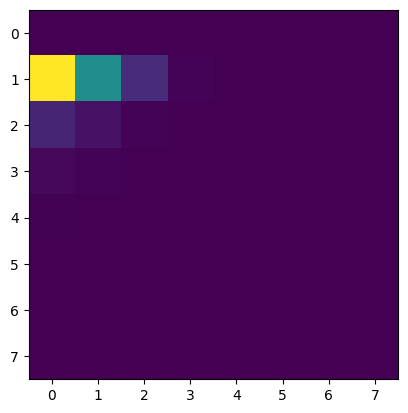

In [88]:
t = model.CHI[2:, :, :, :].sum(axis = (0, 1))
plt.imshow(t)